In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

In [2]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [3]:
stl = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB_n.stl'
xlsx = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\GEO_SIM_v3.xlsx'

In [4]:
full_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.full'
ress_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.rst'

MK = pyFBS.MK_model(ress_file,full_file,no_modes = 200)

MK.mesh.points *= 1000

In [5]:
view3D = pyFBS.display.view3D(show_origin= True)

In [6]:
#view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 0.2)

In [20]:
view3D.plot.add_mesh(MK.mesh, scalars = np.ones(MK.mesh.points.shape[0]),show_scalar_bar = False,name = "mesh",cmap = "coolwarm",show_edges = True)

(vtkRenderingOpenGL2Python.vtkOpenGLActor)000001FF8972EA68

In [8]:
pts = MK.mesh.points.copy()

In [9]:
view3D.take_gif = False

In [21]:
# Priprava animacije oblike
select_mode = 5      
relative_scale = 30

#kreairanje animacije
_modeshape = np.zeros_like(MK.nodes)
for ref,mode in zip(MK.dof_ref,MK.eig_vec[:,select_mode]):
    _modeshape[ref[0]-1,ref[1]] = mode

#samo priprava vsega za onimacijo v pyFBSu
mode_dict = dict()
mode_dict["animation_pts"] = mode_animation(_modeshape,relative_scale,no_points = 60)
mode_dict["mesh"] = MK.mesh
mode_dict["or_pts"] = pts
mode_dict["scalars"] = True
mode_dict["fps"] = 30

#dodajanje animacije v okno
view3D.add_modeshape(mode_dict,run_animation = True)

In [11]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
#df_imp

In [12]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
#df_chn

In [13]:
MK.FRF_synth(df_chn,df_imp,modal_damping = 0.00,frf_type = "accelerance")

In [14]:
freq_R,Y_R,_ = np.load("AB.npy",allow_pickle=True)

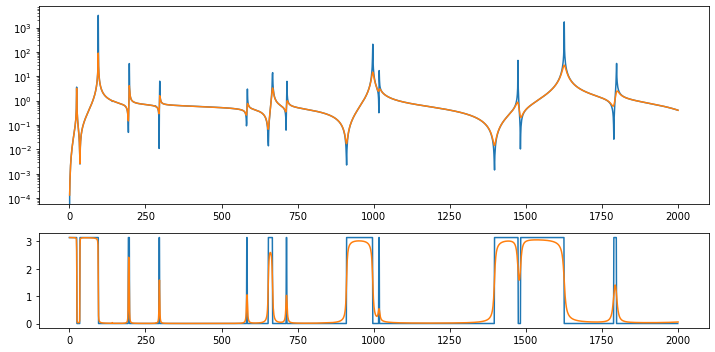

In [18]:
plt.figure(figsize = (12,8))

s1 = -2
s2 = -2
plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[:,s1,s2]))
plt.semilogy(freq_R,np.abs(Y_R[s1,s2]))
#plt.semilogy(freq,np.abs(FRF[-2,-1]),'--')

plt.subplot(413)
plt.plot(MK.freq,np.angle(MK.FRF[:,s1,s2]))
plt.plot(freq_R,np.angle(Y_R[s1,s2]))

#plt.plot(freq,np.angle(FRF[2,0]),'--')